# ARTI 404 - Image Processing
## Lab 4 - Intensity Transformations and Filtering
**Student ID:** 2240005893

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, exposure, color

## Thresholding

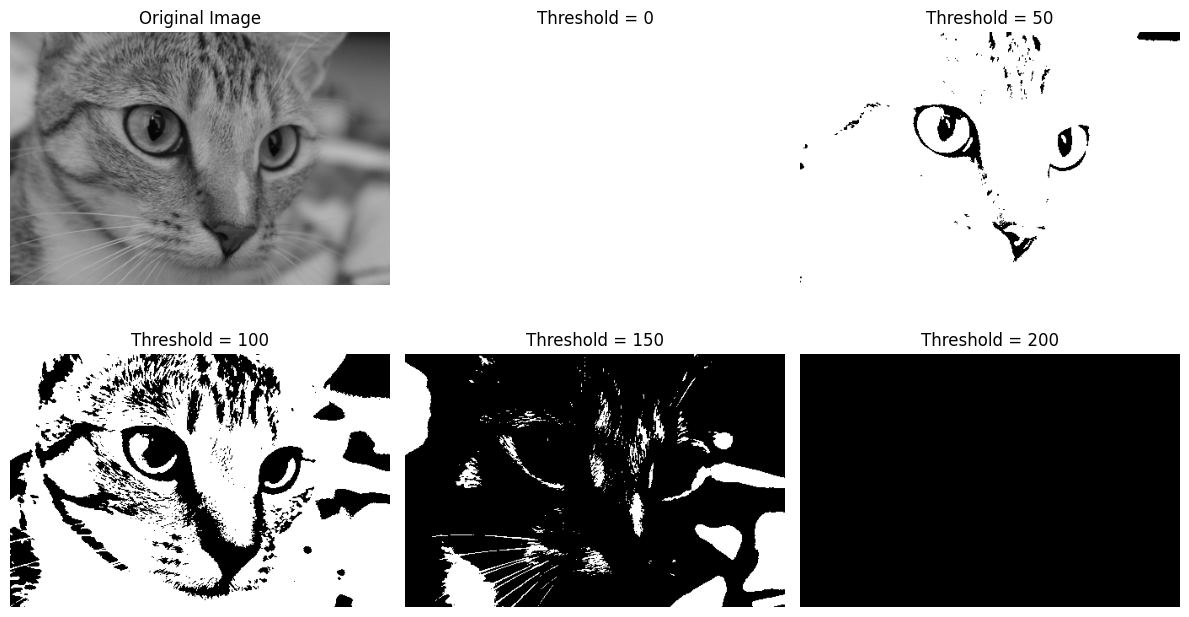

In [9]:
img_threshold = color.rgb2gray(data.chelsea())
img_threshold = (img_threshold * 255).astype(np.uint8)
threshold_values = [0, 50, 100, 150, 200]

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
axes = axes.ravel()
axes[0].imshow(img_threshold, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Original Image')
axes[0].axis('off')

for ax, threshold_value in zip(axes[1:], threshold_values):
    _, thresh = cv2.threshold(img_threshold, threshold_value, 255, cv2.THRESH_BINARY)
    ax.imshow(thresh, cmap='gray', vmin=0, vmax=255)
    ax.set_title(f'Threshold = {threshold_value}')
    ax.axis('off')

plt.tight_layout()
plt.show()

## Histogram Processing Example

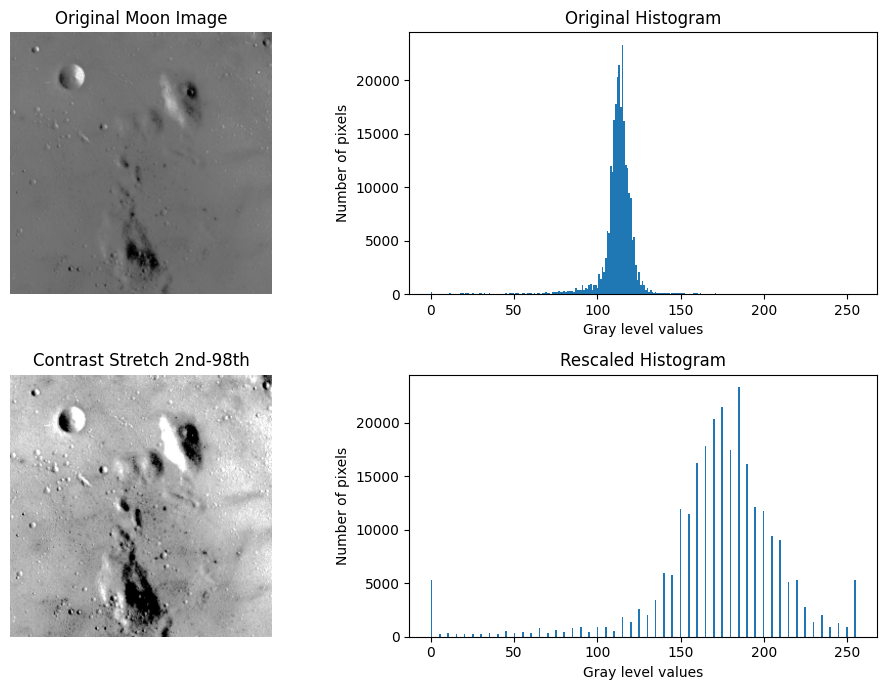

In [10]:
img = data.moon()
p2, p98 = np.percentile(img, (2, 98))
img_rescale = exposure.rescale_intensity(img, in_range=(p2, p98))

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
axes[0, 0].imshow(img, cmap='gray')
axes[0, 0].set_title('Original Moon Image')
axes[0, 0].axis('off')
axes[0, 1].hist(img.ravel(), bins=256, range=(0, 255))
axes[0, 1].set_title('Original Histogram')
axes[0, 1].set_xlabel('Gray level values')
axes[0, 1].set_ylabel('Number of pixels')
axes[1, 0].imshow(img_rescale, cmap='gray')
axes[1, 0].set_title('Contrast Stretch 2nd-98th')
axes[1, 0].axis('off')
axes[1, 1].hist(img_rescale.ravel(), bins=256, range=(0, 255))
axes[1, 1].set_title('Rescaled Histogram')
axes[1, 1].set_xlabel('Gray level values')
axes[1, 1].set_ylabel('Number of pixels')
plt.tight_layout()
plt.show()

## Assessment Task 1
Rescale the Moon image using the 3rd and 80th percentiles.

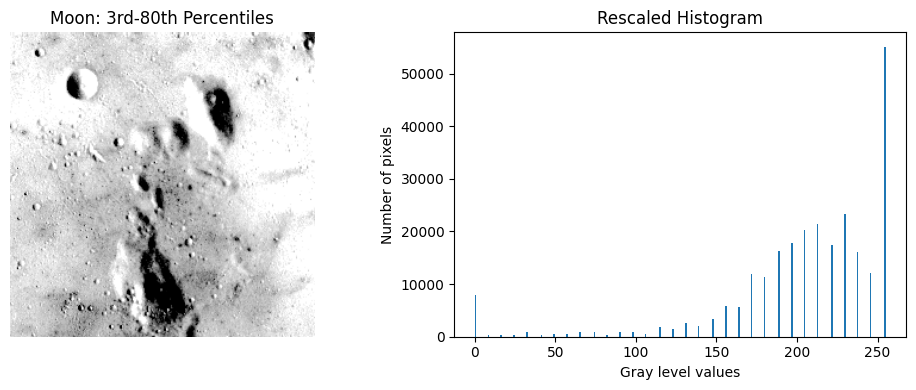

In [11]:
p3, p80 = np.percentile(img, (3, 80))
moon_rescale = exposure.rescale_intensity(img, in_range=(p3, p80))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(moon_rescale, cmap='gray')
axes[0].set_title('Moon: 3rd-80th Percentiles')
axes[0].axis('off')
axes[1].hist(moon_rescale.ravel(), bins=256, range=(0, 255))
axes[1].set_title('Rescaled Histogram')
axes[1].set_xlabel('Gray level values')
axes[1].set_ylabel('Number of pixels')
plt.tight_layout()
plt.show()

## Assessment Task 2
Apply histogram equalization to the Moon image.

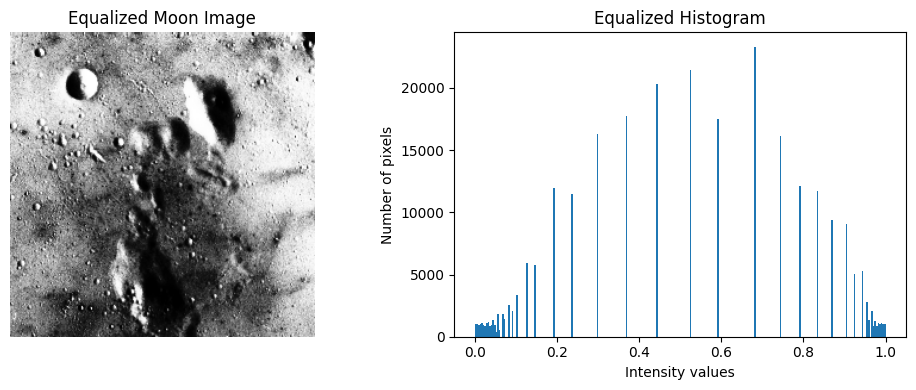

In [12]:
moon_equalized = exposure.equalize_hist(img)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(moon_equalized, cmap='gray')
axes[0].set_title('Equalized Moon Image')
axes[0].axis('off')
axes[1].hist(moon_equalized.ravel(), bins=256, range=(0, 1))
axes[1].set_title('Equalized Histogram')
axes[1].set_xlabel('Intensity values')
axes[1].set_ylabel('Number of pixels')
plt.tight_layout()
plt.show()

## Assessment Task 3
Match the histogram of the Chelsea image to the Rocket reference image.

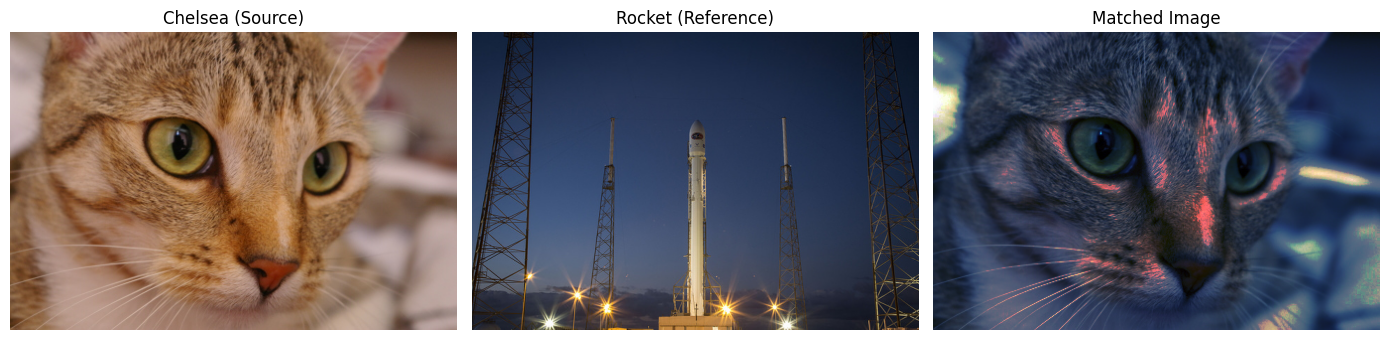

In [13]:
source = data.chelsea()
reference = data.rocket()
matched = exposure.match_histograms(source, reference, channel_axis=-1)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, image, title in zip(
    axes,
    [source, reference, matched],
    ['Chelsea (Source)', 'Rocket (Reference)', 'Matched Image']
):
    ax.imshow(image)
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()

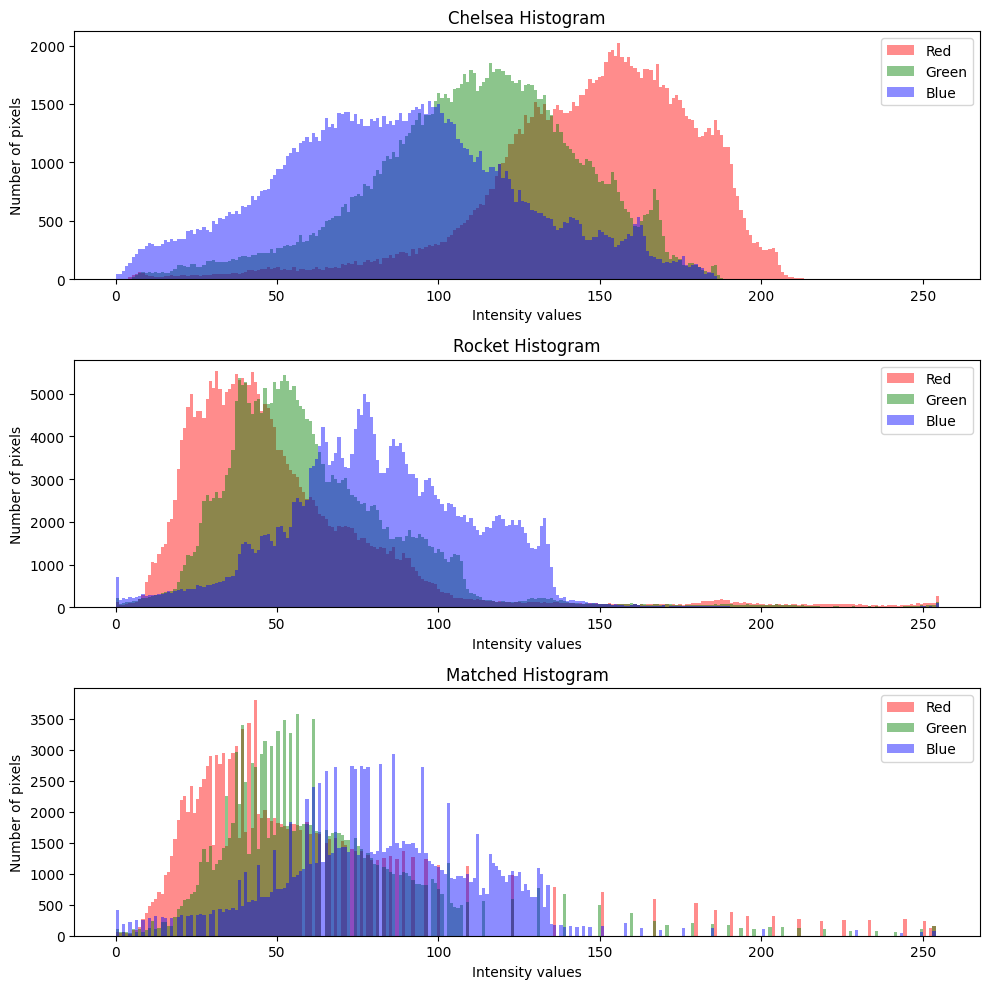

In [14]:
fig, axes = plt.subplots(3, 1, figsize=(10, 10))
colors = ['red', 'green', 'blue']

for ax, image, title in zip(
    axes,
    [source, reference, matched],
    ['Chelsea Histogram', 'Rocket Histogram', 'Matched Histogram']
):
    for channel, color_name in enumerate(colors):
        ax.hist(image[..., channel].ravel(), bins=256, range=(0, 255),
                color=color_name, alpha=0.45, label=color_name.capitalize())
    ax.set_title(title)
    ax.set_xlabel('Intensity values')
    ax.set_ylabel('Number of pixels')
    ax.legend()

plt.tight_layout()
plt.show()